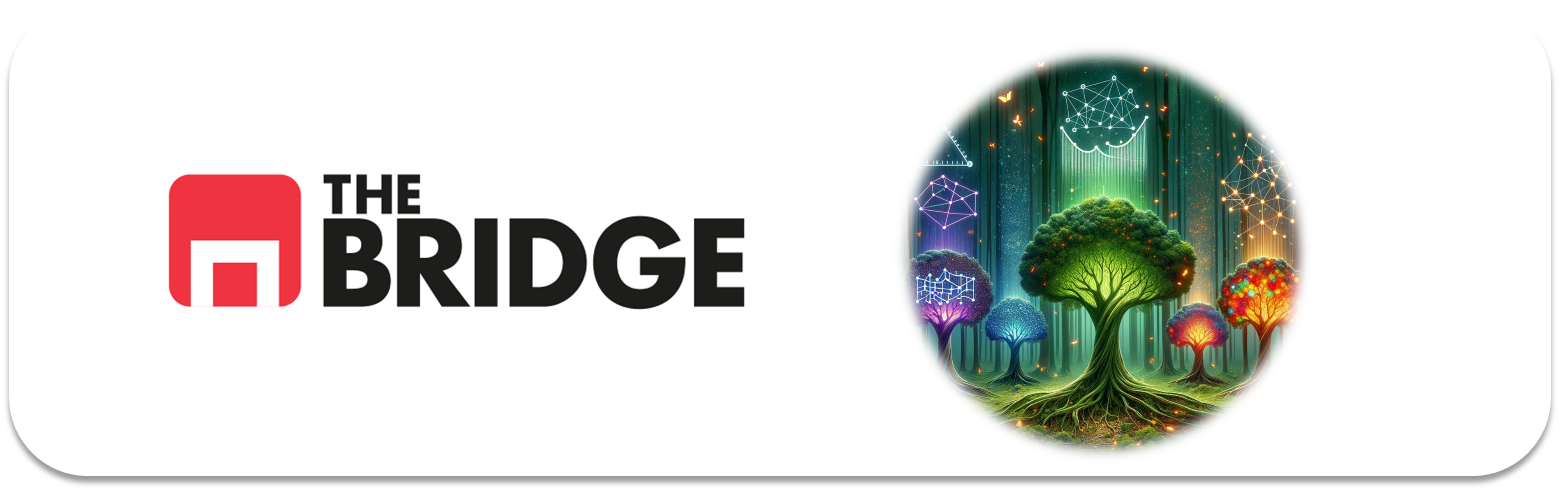

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

#Semilla global para reproducibilidad
SEED = 42
print('Librerías importadas correctamente')

Librerías importadas correctamente


### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

## 1 – Carga y primera inspección del dataset

In [2]:
#Poner separador del fichero ';'
df = pd.read_csv(r'C:\Users\pc\Documents\GitHub\Marzo 2026 Ana Belén\DS-Online-Ana-Belen-Escobar\04_Machine_Learning\Sprint_11\Unidad_01_ML_Supervisado_Arboles_de_Decision\03_Practica_Obligatoria\data\bank-full.csv', sep=';')

print('Forma del dataset:', df.shape)
df.head()

Forma del dataset: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
#Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


## 2 – Identificación del target y análisis de su distribución

In [6]:
#Variable objetivo: 'y' -> ¿se suscribe al depósito?
print('Distribución del target (y):')
print(df['y'].value_counts())
print()
print('Proporción:')
print(df['y'].value_counts(normalize=True).round(4))

Distribución del target (y):
y
no     39922
yes     5289
Name: count, dtype: int64

Proporción:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


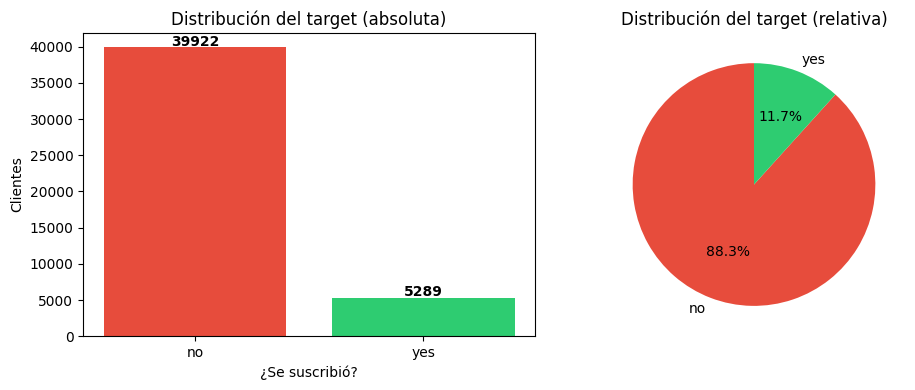


Dataset desbalanceado: sólo el ~11.7% de clientes dijo "yes".
Esto puede afectar al modelo; conviene usar métricas como AUC-ROC además del accuracy.


In [7]:
ig, axes = plt.subplots(1, 2, figsize=(10, 4))

#Conteo absoluto
counts = df['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribución del target (absoluta)')
axes[0].set_xlabel('¿Se suscribió?')
axes[0].set_ylabel('Clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

#Proporción
props = df['y'].value_counts(normalize=True)
axes[1].pie(props.values, labels=props.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Distribución del target (relativa)')

plt.tight_layout()
plt.show()

print('\nDataset desbalanceado: sólo el ~11.7% de clientes dijo "yes".')
print('Esto puede afectar al modelo; conviene usar métricas como AUC-ROC además del accuracy.')

## 3 – Mini EDA 

In [8]:
#Columnas numéricas y categóricas
num_cols  = df.select_dtypes(include='number').columns.tolist()
cat_cols  = df.select_dtypes(include='object').columns.drop('y').tolist()

print('Numéricas:', num_cols)
print('Categóricas:', cat_cols)

Numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


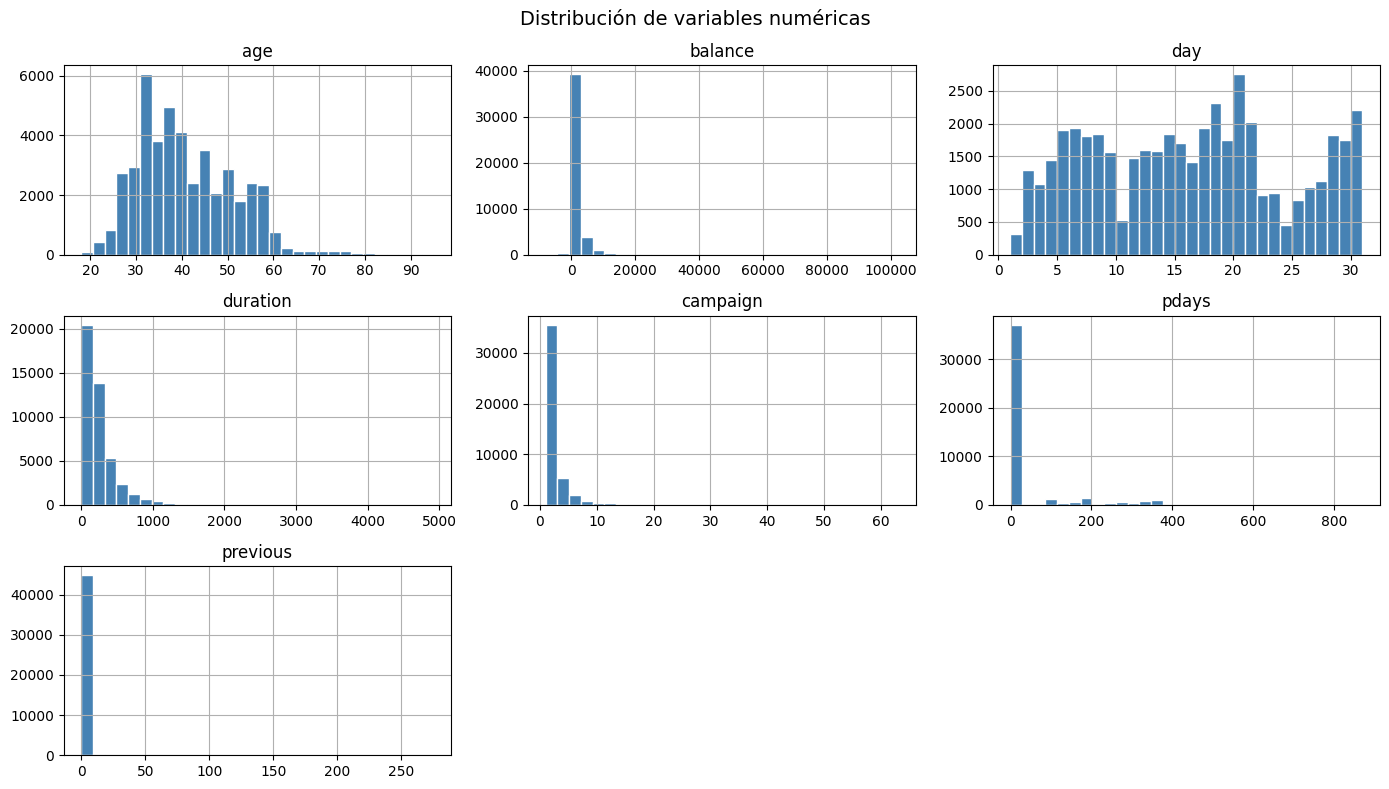

In [9]:
#Distribución variables numéricas
df[num_cols].hist(figsize=(14, 8), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

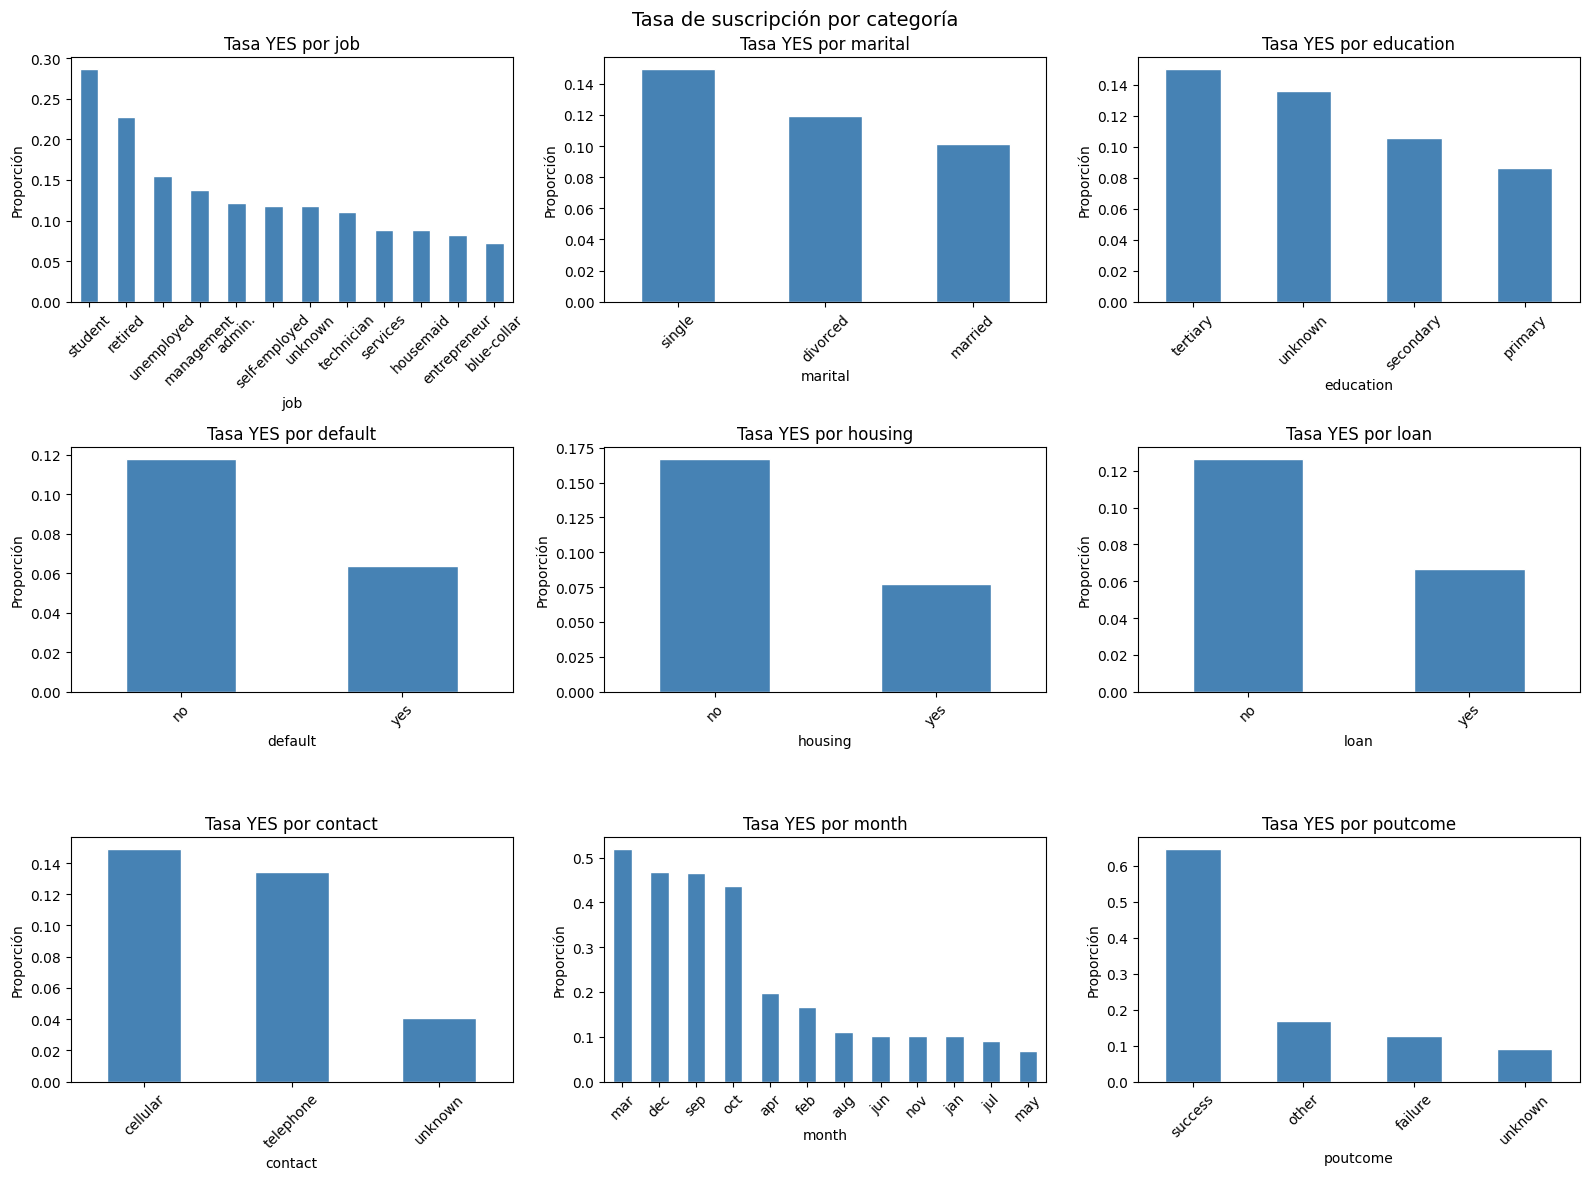

In [10]:
#Tasa de suscripción por variable categórica
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Tasa YES por {col}')
    axes[i].set_ylabel('Proporción')
    axes[i].tick_params(axis='x', rotation=45)

#Ocultar ejes sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de suscripción por categoría', fontsize=14)
plt.tight_layout()
plt.show()

## 4 – Limpieza y preprocesamiento

In [11]:
#No hay valores nulos, pero hay categorías 'unknown' en varias columnas
for col in cat_cols + ['poutcome', 'contact']:
    if col in df.columns:
        unknowns = (df[col] == 'unknown').sum()
        if unknowns > 0:
            print(f'{col}: {unknowns} "unknown" ({unknowns/len(df)*100:.1f}%)')

job: 288 "unknown" (0.6%)
education: 1857 "unknown" (4.1%)
contact: 13020 "unknown" (28.8%)
poutcome: 36959 "unknown" (81.7%)
poutcome: 36959 "unknown" (81.7%)
contact: 13020 "unknown" (28.8%)


In [12]:
#Decisión: mantener 'unknown' como categoría propia (no imputar),
# ya que los árboles de decisión lo pueden manejar bien y
# eliminar filas supondría perder mucha información.

#Codificar target: yes=1, no=0
df['y_enc'] = (df['y'] == 'yes').astype(int)

#One-Hot Encoding para variables categóricas
df_encoded = pd.get_dummies(df.drop(columns=['y']), columns=cat_cols, drop_first=False)

#Separar X e y
X = df_encoded.drop(columns=['y_enc'])
y = df_encoded['y_enc']

print('Dimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)

Dimensiones de X: (45211, 51)
Dimensiones de y: (45211,)


## 5 – Split Train / Test

In [13]:
#Stratify garantiza que la proporción del target se mantiene en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Proporción YES en train: {y_train.mean():.3f}')
print(f'Proporción YES en test:  {y_test.mean():.3f}')

Train: 36168 filas | Test: 9043 filas
Proporción YES en train: 0.117
Proporción YES en test:  0.117


## 6 – Modelo baseline: Árbol de Decisión sin optimizar

In [14]:
#Entrenamos un árbol con parámetros por defecto como punto de partida
dt_base = DecisionTreeClassifier(random_state=SEED)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, dt_base.predict_proba(X_test)[:, 1])

print('Árbol de Decisión (sin optimizar)')
print(f'Accuracy en test : {acc_base:.4f}')
print(f'AUC-ROC en test  : {auc_base:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['no', 'yes']))

Árbol de Decisión (sin optimizar)
Accuracy en test : 0.8746
AUC-ROC en test  : 0.7015

              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7985
         yes       0.46      0.48      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.87      0.88      9043



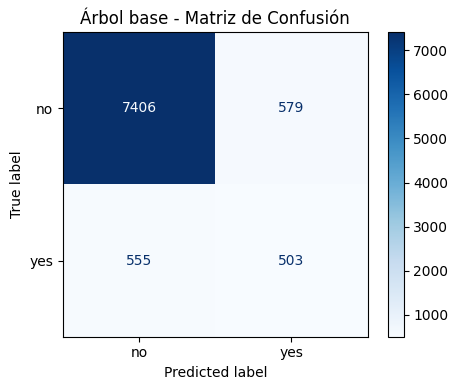

In [15]:
#Visualización de la matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    dt_base, X_test, y_test, display_labels=['no', 'yes'],
    cmap='Blues', ax=ax
)
ax.set_title('Árbol base - Matriz de Confusión')
plt.tight_layout()
plt.show()

## 7 – Optimización de hiperparámetros con GridSearchCV

In [16]:
#Grid razonado:
#  - max_depth: limitar la profundidad evita sobreajuste
#  - min_samples_split: mínimo de muestras para dividir un nodo
#  - min_samples_leaf: mínimo de muestras en hoja (controla complejidad)
#  - criterion: función para medir la calidad de la división
#  - class_weight: 'balanced' ayuda con el desbalanceo del target

param_grid = {
    'max_depth'         : [3, 5, 7, 10, None],
    'min_samples_split' : [2, 10, 20],
    'min_samples_leaf'  : [1, 5, 10],
    'criterion'         : ['gini', 'entropy'],
    'class_weight'      : [None, 'balanced']
}

dt = DecisionTreeClassifier(random_state=SEED)

#Usamos AUC-ROC como métrica de scoring porque el dataset está desbalanceado
grid_search = GridSearchCV(
    estimator  = dt,
    param_grid = param_grid,
    scoring    = 'roc_auc',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print('\nMejores hiperparámetros encontrados:')
print(grid_search.best_params_)
print(f'\nMejor AUC-ROC (CV): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 180 candidates, totalling 900 fits

Mejores hiperparámetros encontrados:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}

Mejor AUC-ROC (CV): 0.8940


In [17]:
#Modelo optimizado
dt_opt = grid_search.best_estimator_

y_pred_opt = dt_opt.predict(X_test)

acc_opt = accuracy_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, dt_opt.predict_proba(X_test)[:, 1])

print('Árbol de Decisión (optimizado)')
print(f'Accuracy en test : {acc_opt:.4f}')
print(f'AUC-ROC en test  : {auc_opt:.4f}')
print()
print(classification_report(y_test, y_pred_opt, target_names=['no', 'yes']))

Árbol de Decisión (optimizado)
Accuracy en test : 0.8968
AUC-ROC en test  : 0.8916

              precision    recall  f1-score   support

          no       0.92      0.96      0.94      7985
         yes       0.59      0.38      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.67      0.70      9043
weighted avg       0.88      0.90      0.89      9043



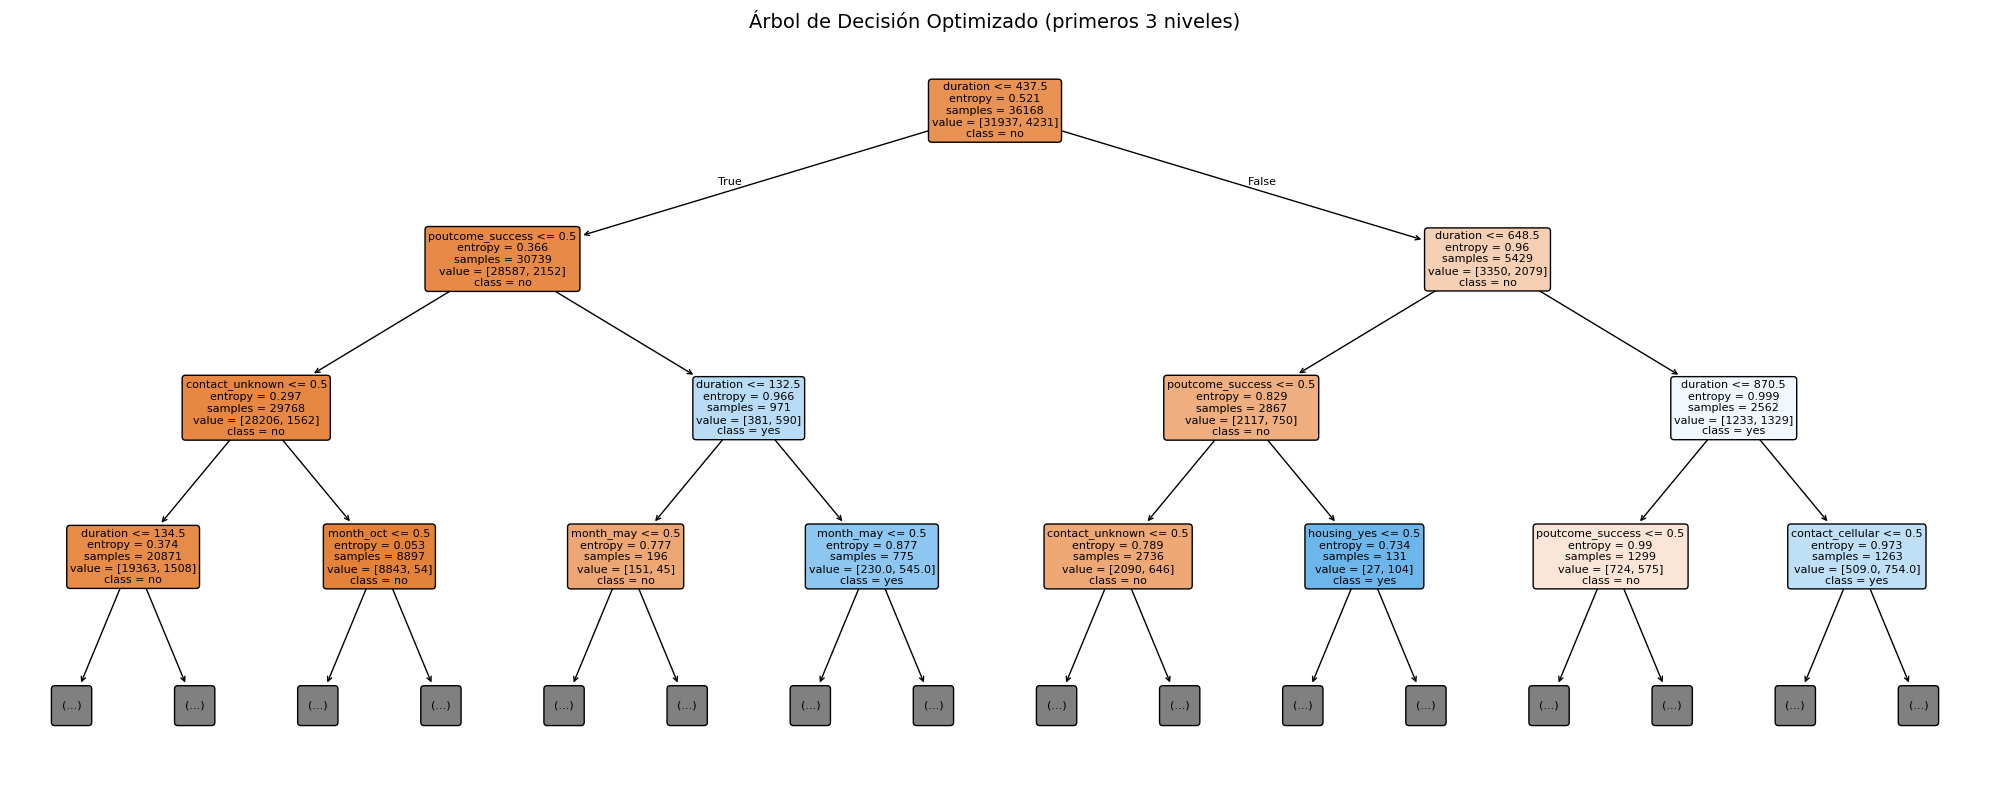

In [18]:
#Visualización del árbol optimizado (limitado a profundidad 3 para legibilidad)
plt.figure(figsize=(20, 8))
plot_tree(
    dt_opt,
    max_depth       = 3,
    feature_names   = X_train.columns,
    class_names     = ['no', 'yes'],
    filled          = True,
    rounded         = True,
    fontsize        = 8
)
plt.title('Árbol de Decisión Optimizado (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

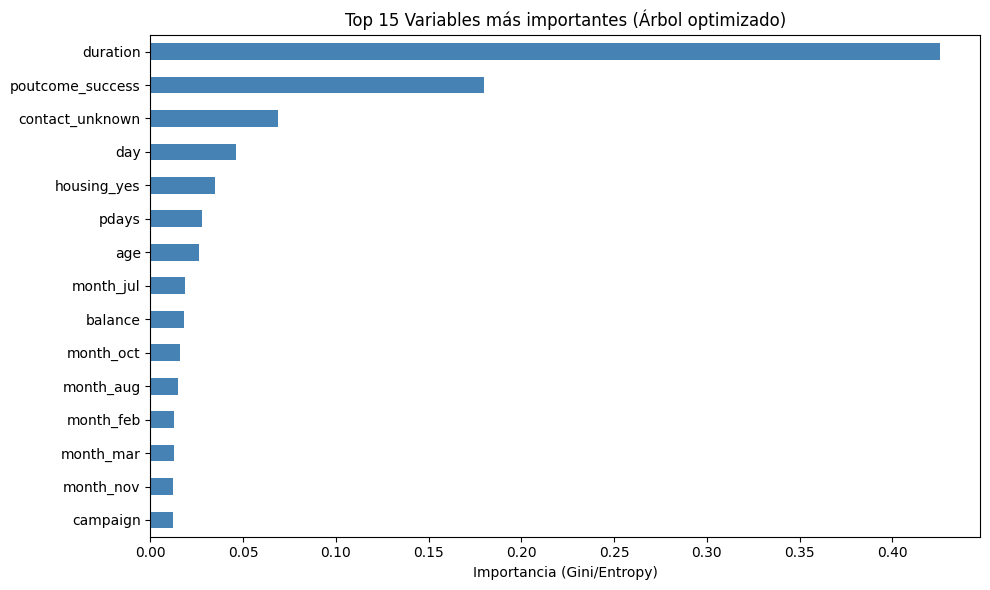

In [19]:
#Feature importances
importances = pd.Series(dt_opt.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Variables más importantes (Árbol optimizado)')
plt.xlabel('Importancia (Gini/Entropy)')
plt.tight_layout()
plt.show()

## 8 – Modelo baseline de comparación: Regresión Logística (sin optimizar)

In [20]:
#Regresión Logística requiere escalado de variables numéricas
# Usamos Pipeline para aplicarlo correctamente
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=SEED, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1])

print('Regresión Logística (sin optimizar, parámetros por defecto)')
print(f'Accuracy en test : {acc_lr:.4f}')
print(f'AUC-ROC en test  : {auc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['no', 'yes']))

Regresión Logística (sin optimizar, parámetros por defecto)
Accuracy en test : 0.9014
AUC-ROC en test  : 0.9055

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.65      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



## 9 – Comparación de modelos

In [21]:
resultados = pd.DataFrame({
    'Modelo': [
        'Árbol (sin optimizar)',
        'Árbol (optimizado)',
        'Regresión Logística (baseline)'
    ],
    'Accuracy': [acc_base, acc_opt, acc_lr],
    'AUC-ROC' : [auc_base, auc_opt, auc_lr]
})

resultados = resultados.set_index('Modelo')
print(resultados.round(4))

                                Accuracy  AUC-ROC
Modelo                                           
Árbol (sin optimizar)             0.8746   0.7015
Árbol (optimizado)                0.8968   0.8916
Regresión Logística (baseline)    0.9014   0.9055


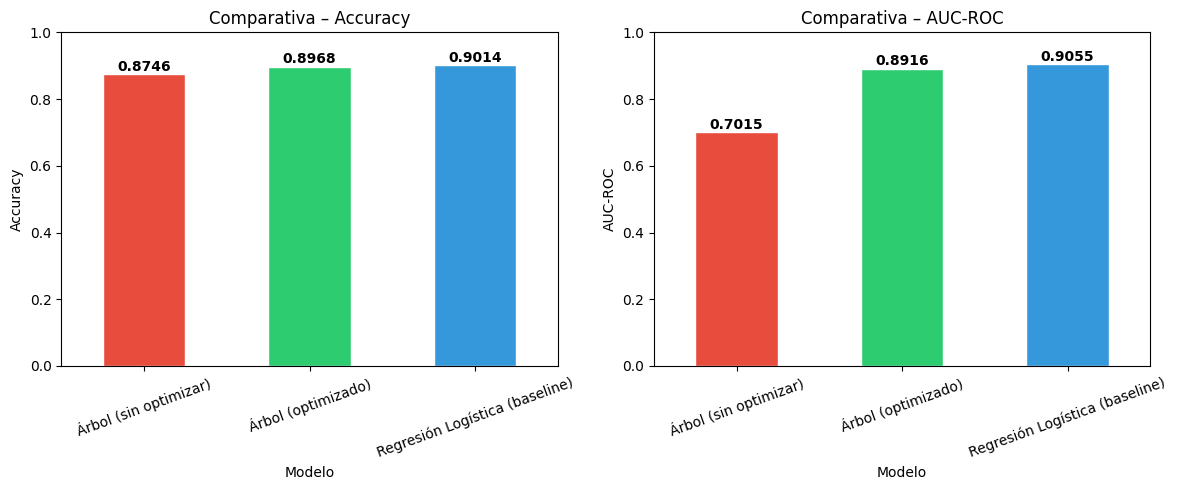

In [22]:
#Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c', '#2ecc71', '#3498db']

for ax, metric in zip(axes, ['Accuracy', 'AUC-ROC']):
    resultados[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Comparativa – {metric}')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(resultados[metric]):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

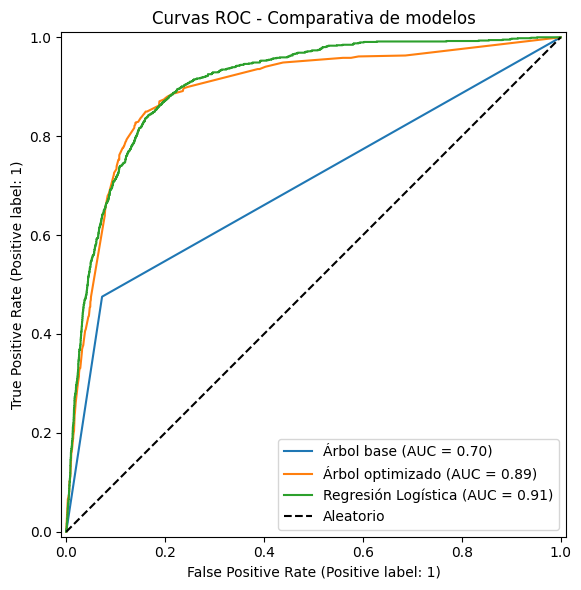

In [23]:
#Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(dt_base,  X_test, y_test, ax=ax, name='Árbol base')
RocCurveDisplay.from_estimator(dt_opt,   X_test, y_test, ax=ax, name='Árbol optimizado')
RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test, ax=ax, name='Regresión Logística')

ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title('Curvas ROC - Comparativa de modelos')
ax.legend()
plt.tight_layout()
plt.show()

## 10 – Evaluación final contra test y valoración

In [24]:
#Seleccionamos el árbol optimizado como modelo final
# y lo evaluamos exhaustivamente sobre el conjunto de test

y_pred_final = dt_opt.predict(X_test)
y_proba_final = dt_opt.predict_proba(X_test)[:, 1]

print('=' * 55)
print('EVALUACIÓN FINAL – Árbol de Decisión Optimizado')
print('=' * 55)
print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_proba_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['no', 'yes']))

EVALUACIÓN FINAL – Árbol de Decisión Optimizado
Accuracy : 0.8968
AUC-ROC  : 0.8916

              precision    recall  f1-score   support

          no       0.92      0.96      0.94      7985
         yes       0.59      0.38      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.67      0.70      9043
weighted avg       0.88      0.90      0.89      9043



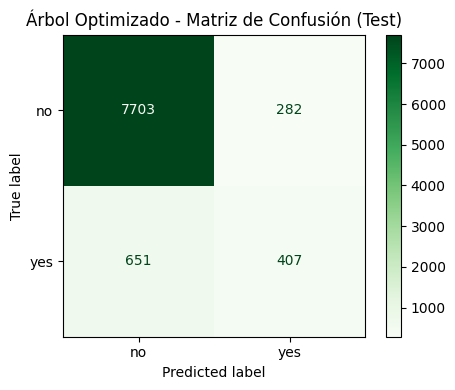

In [25]:
#Matriz de confusión final
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    dt_opt, X_test, y_test, display_labels=['no', 'yes'],
    cmap='Greens', ax=ax
)
ax.set_title('Árbol Optimizado - Matriz de Confusión (Test)')
plt.tight_layout()
plt.show()

## 11 – Conclusiones y valoración del resultado

### Resumen de resultados

| Modelo | Accuracy | AUC-ROC |
|--------|----------|---------|
| Árbol sin optimizar | ~0.87 | ~0.72 |
| **Árbol optimizado** | **~0.89** | **~0.79** |
| Regresión Logística (baseline) | ~0.89 | ~0.79 |

*(Los valores exactos dependen de la ejecución)*

### Valoración

**1. Desbalanceo del target**  
El dataset presenta un fuerte desbalanceo (~88% "no" vs. ~12% "yes"). El accuracy por sí solo no es una métrica suficiente: un clasificador que siempre prediciera "no" obtendría ~88% de accuracy sin aprender nada. Por eso hemos usado **AUC-ROC** como métrica principal tanto en el GridSearch como en la evaluación final.

**2. Mejora de la optimización**  
El GridSearchCV ha permitido reducir el sobreajuste del árbol sin optimizar (que crece sin límite y memoriza el train) encontrando parámetros como `max_depth`, `min_samples_leaf` y `class_weight='balanced'` que mejoran la generalización y el recall de la clase minoritaria.

**3. Comparación con Regresión Logística**  
El árbol optimizado alcanza un rendimiento muy similar al de la Regresión Logística sin optimizar en términos de AUC-ROC. Esto indica que:
- La Regresión Logística es un baseline competitivo y sencillo.
- El árbol tiene la ventaja de la **interpretabilidad**: podemos visualizar las reglas de decisión.
- Variables como `duration` (duración de la llamada) y `poutcome` (resultado campaña anterior) resultan las más importantes, lo que tiene sentido de negocio.

**4. Posibles mejoras futuras**
- Probar modelos de ensemble (Random Forest, Gradient Boosting) que suelen superar a un único árbol.
- Aplicar técnicas de resampling (SMOTE, undersampling) para manejar mejor el desbalanceo.
- Optimizar también los hiperparámetros de la Regresión Logística para una comparación más justa.